In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, chi2_contingency, ttest_ind

In [ ]:
data_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
data = pd.read_csv(data_path)

In [ ]:
# pd.set_option('display.max_columns', None)

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# invalid_rows = data[pd.to_numeric(data["TotalCharges"], errors="coerce").isna()]
# len(invalid_rows)

11

# Explore Data

## Churn Rate (26.54%)

In [5]:
data.groupby("Churn")["customerID"].nunique()

Churn
No     5174
Yes    1869
Name: customerID, dtype: int64

In [ ]:
1869 / (5174+1869) * 100

26.536987079369588

## Helpers

In [12]:
def boxplot(y, data, x="Churn"):
    sns.boxplot(x=x, y=y, data=data)

    plt.title(f"{y} by {x}".title())
    plt.show()

In [13]:
def countplot(hue, data, x="Churn"):
    sns.countplot(x=x, hue=hue, data=data)

    plt.title(f"{hue} by {x}".title())
    plt.show()

In [14]:
def scatterplot(x, data, y="rate"):
    sns.scatterplot(x=x, y=y, data=data)

    plt.ylabel("Churn Rate (%)")
    plt.title(f"Churn Rate by {x}")
    plt.show()

In [15]:
def barplot(x, data, y="rate"):
    sns.barplot(
        data=data,
        x=x,
        y=y,
        hue=x
    )

    plt.ylabel("Churn Rate (%)")
    plt.title(f"Churn Rate by {x}")
    plt.xticks(rotation=45, fontsize=8)
    plt.show()

In [ ]:
def t_test_binary(df, num_col, binary_col):
    """
    Measures difference between a continuous variable and a binary categorical variable.

    H0: There is no difference in means of the numeric variable between the two groups.
    H1: There is a difference in means between the two groups.

    If p-value < 0.05, reject H0 → the numeric feature is significantly different across groups.

    Returns:
        p-value and effect size (Cohen's d)
    """
    # Clean data
    df_clean = df[[num_col, binary_col]].copy()
    df_clean = df_clean.dropna()
    print(f"Dropped {len(df) - len(df_clean)} rows")

    # drop NA
    df_clean = df[[num_col, binary_col]].copy().dropna()

    # split groups safely
    group1 = df_clean[df_clean[binary_col] == "Yes"][num_col]
    group2 = df_clean[df_clean[binary_col] == "No"][num_col]

    # t-test
    t_stat, p = ttest_ind(group1, group2, equal_var=False)

    # Effect size (Cohen's d)
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()

    pooled_std = np.sqrt((std1**2 + std2**2) / 2)
    d = (mean1 - mean2) / pooled_std

    p = round(p, 2)
    d = round(d, 2)

    if p < 0.05:
        print(f"As p={p} < 0.05, {num_col} is significantly different between {binary_col} groups (Cohen's d={d}).")
    else:
        print(f"As p={p} >= 0.05, {num_col} is NOT significantly different between {binary_col} groups (Cohen's d={d}).")

In [17]:
def chi_square(df, cat1, cat2):
    """
    Measures association between two categorical variables.
    
    H0: There is no relationship between Category 1 and Category 2 (e.g., Gender and Churn).
    H1: There is a relationship between Category 1 and Category 2.

    If p-value < 0.05, reject Null Hypothesis, i.e., there is some relationship between
    Category 1 and Category 2.

    Returns:
        p-value and results of significance test.
    """
    # Drop NA
    df_cat = df[[cat1, cat2]].copy().dropna()

    # Create contingency table
    contingency_table = pd.crosstab(df_cat[cat1], df_cat[cat2])

    # Chi2 test
    chi2, p, _, _ = chi2_contingency(contingency_table)
    p = round(p, 2)

    # cramer's v - how strong the relationship is
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    
    phi2 = chi2 / n
    
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

    if p < 0.05:
        print(f"As p={p} < 0.05, {cat1} is significantly associated with {cat2} (Cramer's v={v}).")
    else:
        print(f"As p={p} >= 0.05, {cat1} is NOT significantly associated with {cat2} (Cramer's v={v}).")

## Explore Features

### Continuous Variables

Dropped 0 rows
As p=0.0 < 0.05, MonthlyCharges is significantly different between Churn groups (Cohen's d=0.47).
Pearson Correlation: 0.10695290192483636
p-value: 0.0012327125776173664


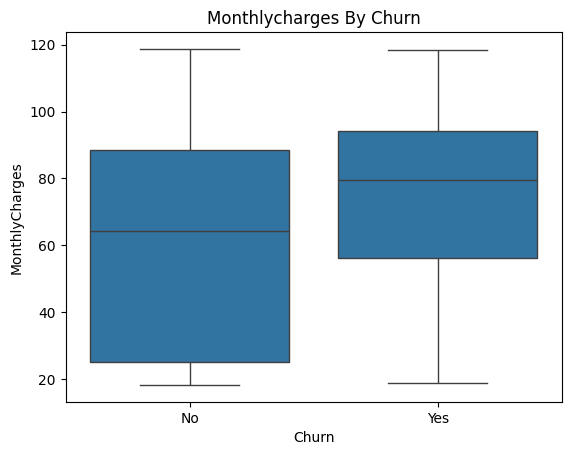

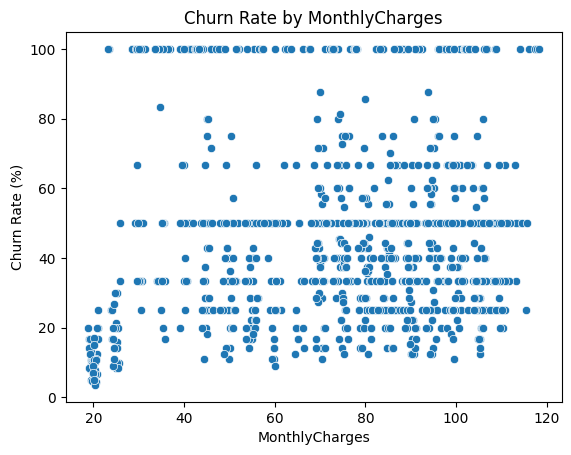

Dropped 11 rows
As p=0.0 < 0.05, TotalCharges is significantly different between Churn groups (Cohen's d=-0.48).
Pearson Correlation: 0.19681718169656626
p-value: 1.3845278406774085e-16


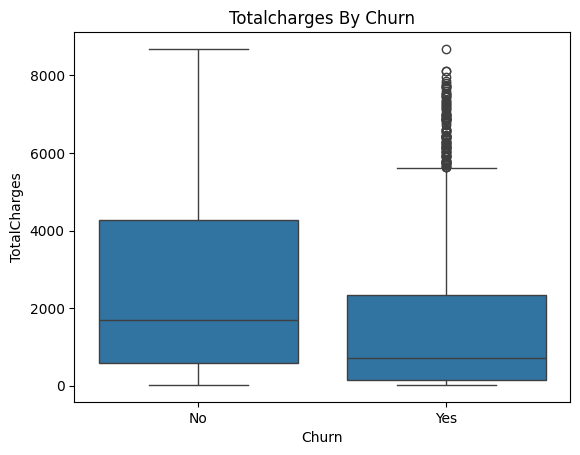

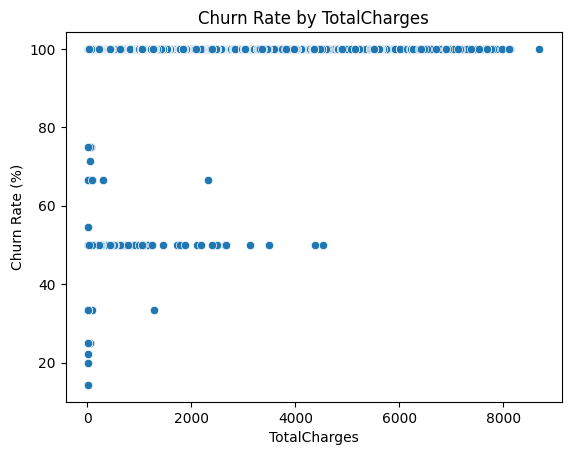

Dropped 0 rows
As p=0.0 < 0.05, tenure is significantly different between Churn groups (Cohen's d=-0.89).
Pearson Correlation: -0.8983490185053685
p-value: 1.035217063278652e-26


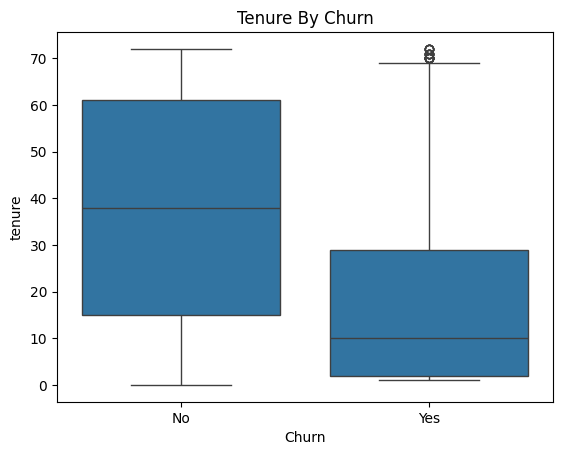

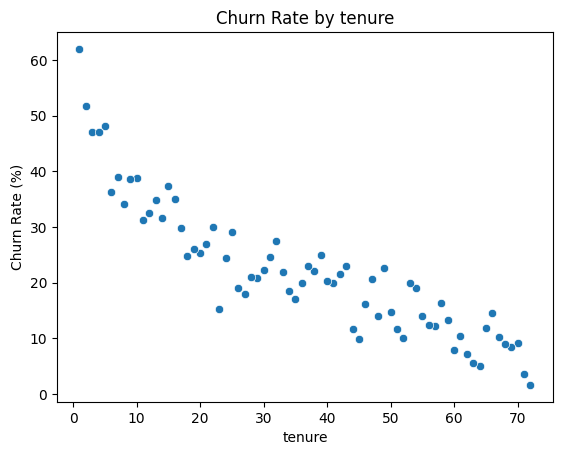

In [20]:
for col in ["MonthlyCharges", "TotalCharges", "tenure"]:
    churn_rate = data.groupby(col)["Churn"].value_counts(normalize=True).rename("rate").mul(100).reset_index().sort_values(by="Churn", ascending=False)
    churn_yes = churn_rate[churn_rate["Churn"] == "Yes"]

    data[col] = pd.to_numeric(data[col], errors="coerce")

    # t test
    t_test_binary(df=data, num_col=col, binary_col="Churn")

    # calculate pearson's r
    corr, p_val = pearsonr(churn_yes[col], churn_yes["rate"])
    print(f"Pearson Correlation: {corr}")
    print(f"p-value: {p_val}")

    # plot
    boxplot(y=col, data=data, x="Churn")
    scatterplot(x=col, data=churn_yes)

### Categorical Variables

In [ ]:
exc_cols = ["MonthlyCharges", "TotalCharges", "customerID", "Churn"]
cat_cols = [col for col in data.columns if col not in exc_cols]

As p=0.49 >= 0.05, gender is NOT significantly associated with Churn (Cramer's v=0.0).


,gender,Churn,rate
1,Female,Yes,26.920872
3,Male,Yes,26.160338
0,Female,No,73.079128
2,Male,No,73.839662


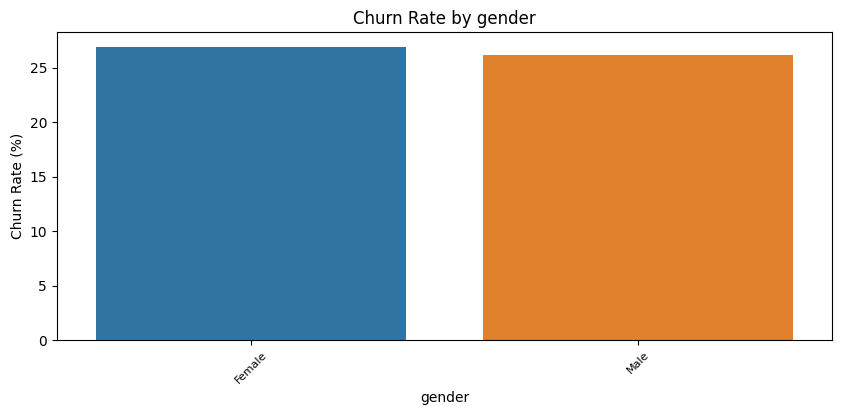

As p=0.0 < 0.05, SeniorCitizen is significantly associated with Churn (Cramer's v=0.14999108255137).


,SeniorCitizen,Churn,rate
1,0,Yes,23.606168
3,1,Yes,41.681261
0,0,No,76.393832
2,1,No,58.318739


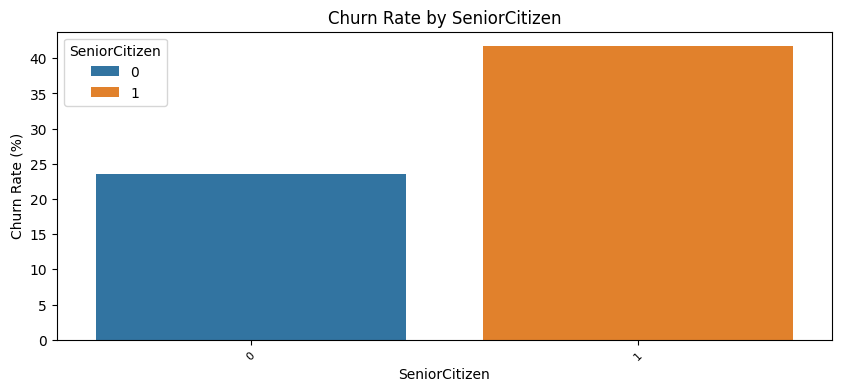

As p=0.0 < 0.05, Partner is significantly associated with Churn (Cramer's v=0.14966271044155077).


,Partner,Churn,rate
1,No,Yes,32.957979
3,Yes,Yes,19.664903
0,No,No,67.042021
2,Yes,No,80.335097


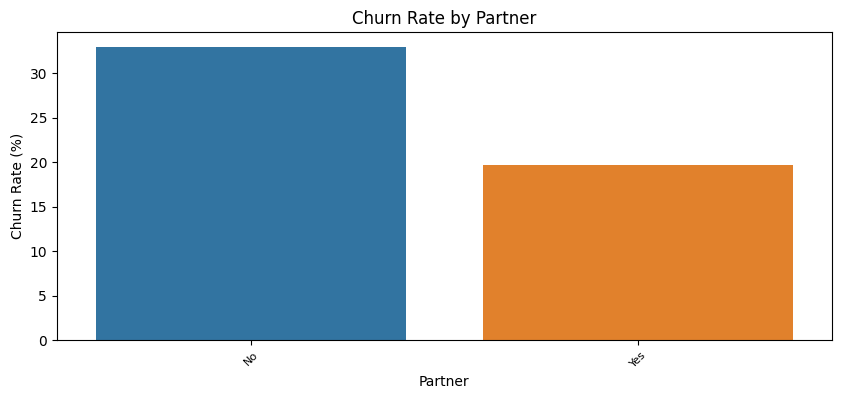

As p=0.0 < 0.05, Dependents is significantly associated with Churn (Cramer's v=0.1634481432749282).


,Dependents,Churn,rate
1,No,Yes,31.279140
3,Yes,Yes,15.450237
0,No,No,68.720860
2,Yes,No,84.549763


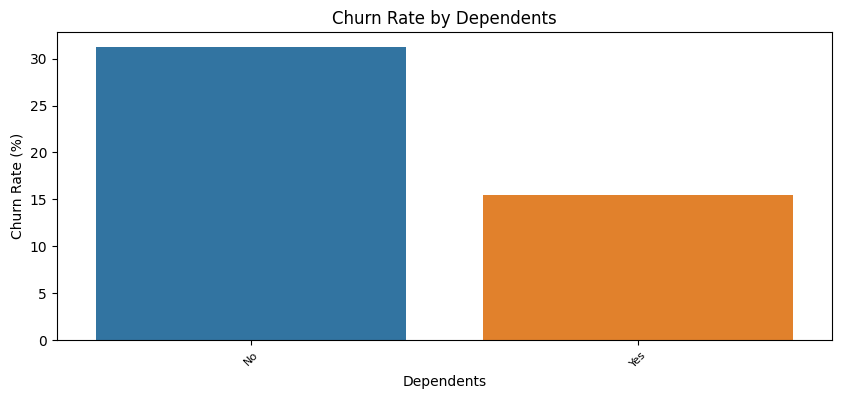

As p=0.0 < 0.05, tenure is significantly associated with Churn (Cramer's v=0.3755750400129582).


,tenure,Churn,rate
72,36,Yes,20.000000
50,25,Yes,29.113924
94,47,Yes,20.588235
92,46,Yes,16.216216
90,45,Yes,9.836066
...,...,...,...
83,42,No,78.461538
81,41,No,80.000000
33,17,No,70.114943
79,40,No,79.687500


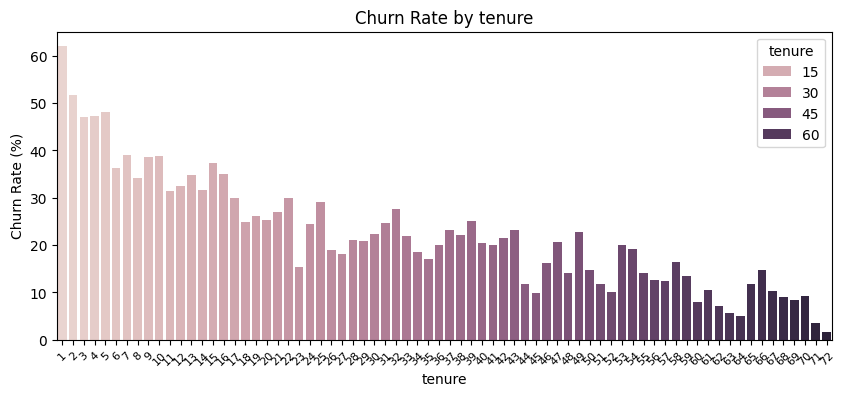

As p=0.34 >= 0.05, PhoneService is NOT significantly associated with Churn (Cramer's v=0.0).


,PhoneService,Churn,rate
1,No,Yes,24.926686
3,Yes,Yes,26.709637
0,No,No,75.073314
2,Yes,No,73.290363


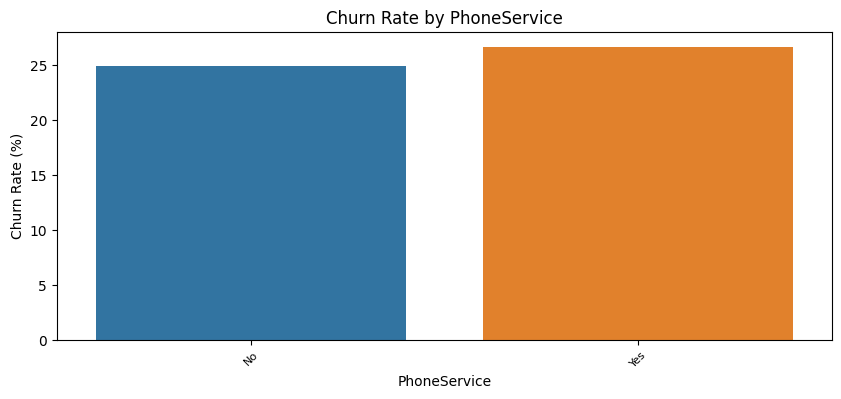

As p=0.0 < 0.05, MultipleLines is significantly associated with Churn (Cramer's v=0.03639958908232507).


,MultipleLines,Churn,rate
1,No,Yes,25.044248
3,No phone service,Yes,24.926686
5,Yes,Yes,28.609896
0,No,No,74.955752
2,No phone service,No,75.073314
4,Yes,No,71.390104


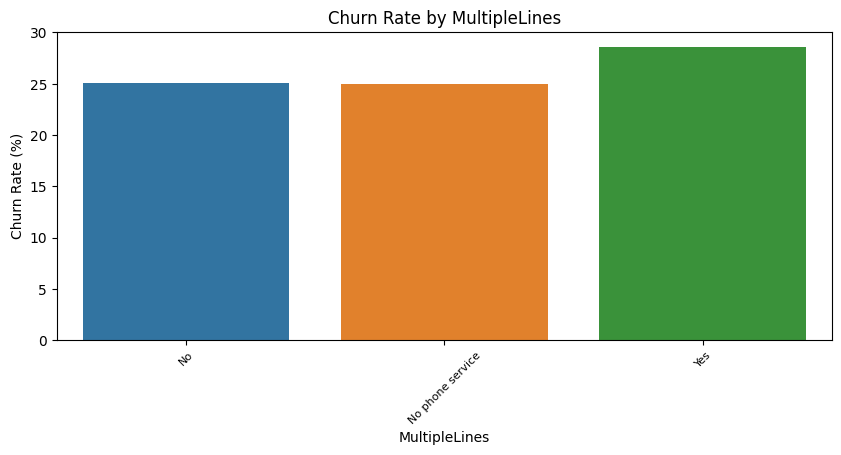

As p=0.0 < 0.05, InternetService is significantly associated with Churn (Cramer's v=0.3220367323307425).


,InternetService,Churn,rate
1,DSL,Yes,18.959108
3,Fiber optic,Yes,41.892765
5,No,Yes,7.404980
0,DSL,No,81.040892
2,Fiber optic,No,58.107235
4,No,No,92.595020


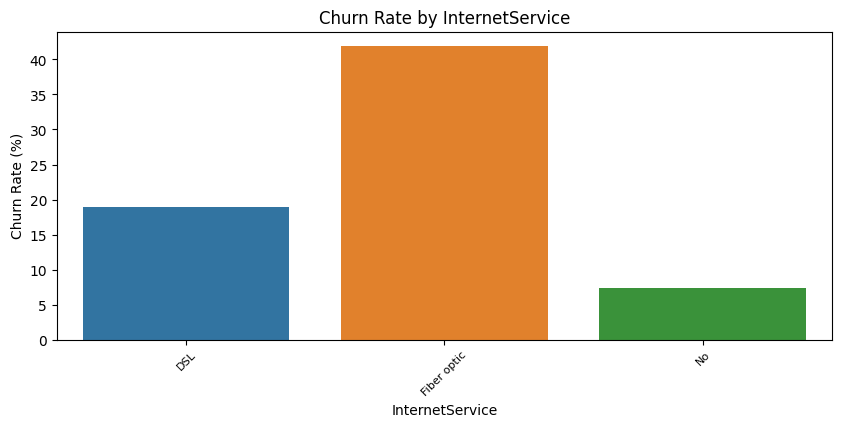

As p=0.0 < 0.05, OnlineSecurity is significantly associated with Churn (Cramer's v=0.34701606688272874).


,OnlineSecurity,Churn,rate
1,No,Yes,41.766724
3,No internet service,Yes,7.404980
5,Yes,Yes,14.611194
0,No,No,58.233276
2,No internet service,No,92.595020
4,Yes,No,85.388806


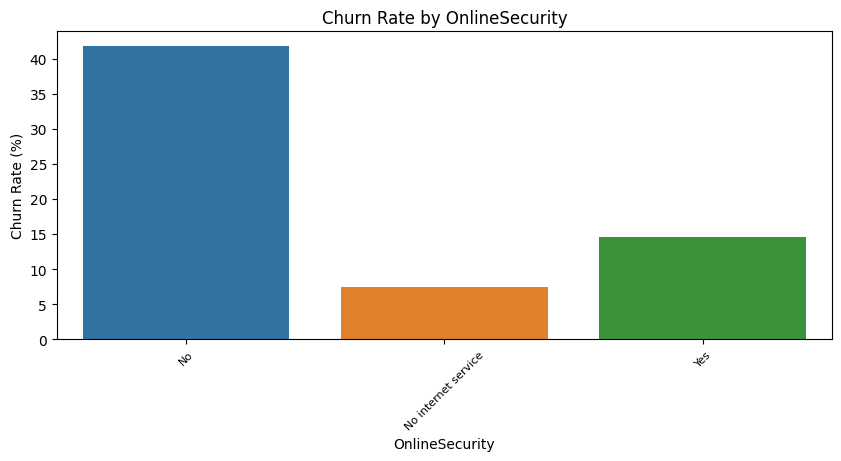

As p=0.0 < 0.05, OnlineBackup is significantly associated with Churn (Cramer's v=0.291850036724674).


,OnlineBackup,Churn,rate
1,No,Yes,39.928756
3,No internet service,Yes,7.404980
5,Yes,Yes,21.531494
0,No,No,60.071244
2,No internet service,No,92.595020
4,Yes,No,78.468506


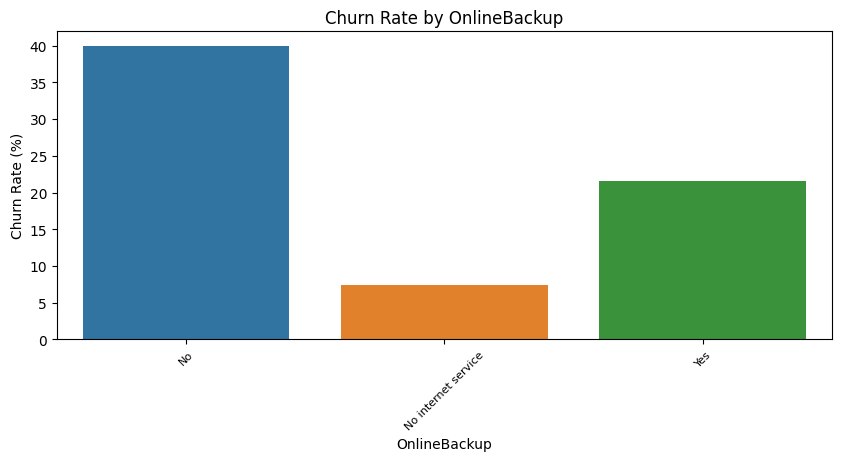

As p=0.0 < 0.05, DeviceProtection is significantly associated with Churn (Cramer's v=0.28109492388964397).


,DeviceProtection,Churn,rate
1,No,Yes,39.127625
3,No internet service,Yes,7.404980
5,Yes,Yes,22.502064
0,No,No,60.872375
2,No internet service,No,92.595020
4,Yes,No,77.497936


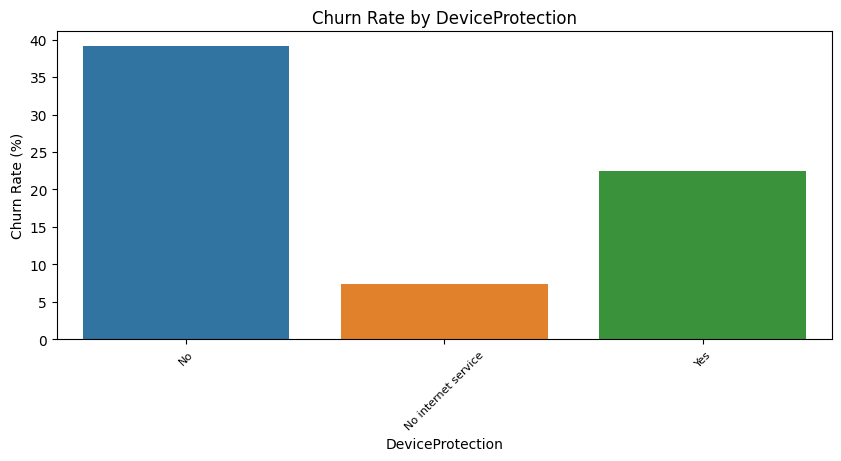

As p=0.0 < 0.05, TechSupport is significantly associated with Churn (Cramer's v=0.3425261587493695).


,TechSupport,Churn,rate
1,No,Yes,41.635474
3,No internet service,Yes,7.404980
5,Yes,Yes,15.166341
0,No,No,58.364526
2,No internet service,No,92.595020
4,Yes,No,84.833659


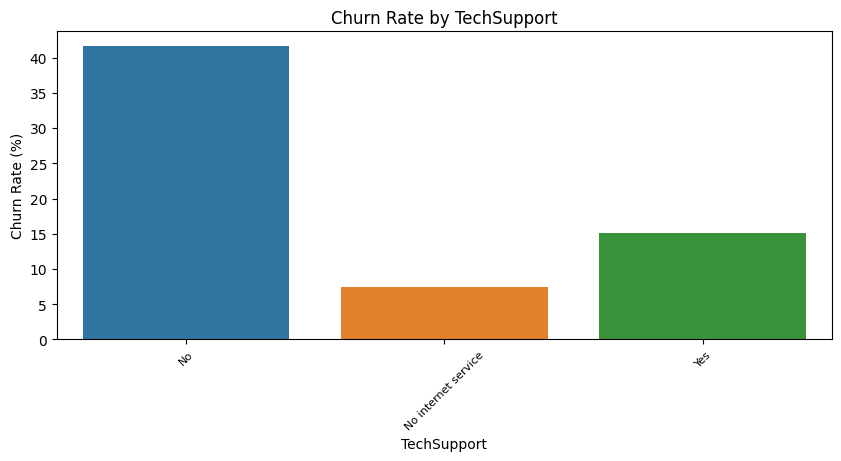

As p=0.0 < 0.05, StreamingTV is significantly associated with Churn (Cramer's v=0.22990176915403474).


,StreamingTV,Churn,rate
1,No,Yes,33.523132
3,No internet service,Yes,7.404980
5,Yes,Yes,30.070188
0,No,No,66.476868
2,No internet service,No,92.595020
4,Yes,No,69.929812


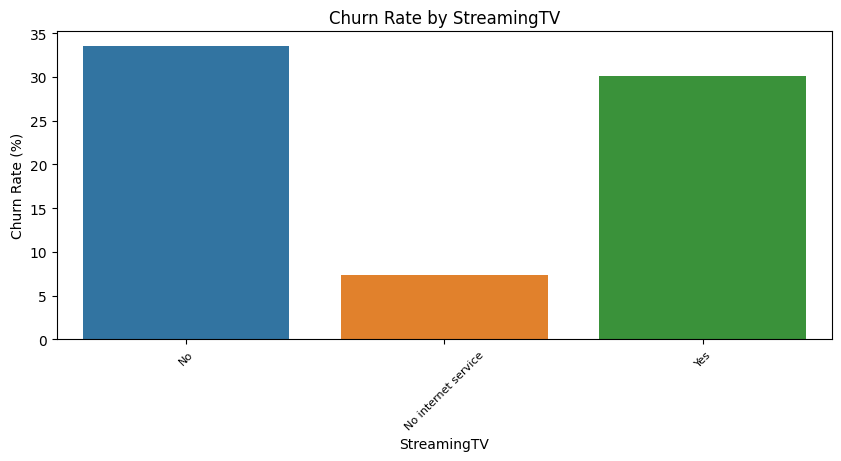

As p=0.0 < 0.05, StreamingMovies is significantly associated with Churn (Cramer's v=0.23035147282444215).


,StreamingMovies,Churn,rate
1,No,Yes,33.680431
3,No internet service,Yes,7.404980
5,Yes,Yes,29.941435
0,No,No,66.319569
2,No internet service,No,92.595020
4,Yes,No,70.058565


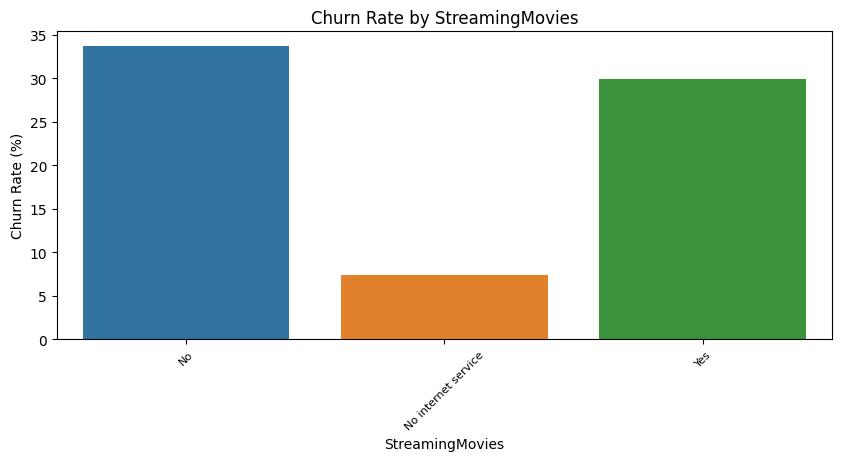

As p=0.0 < 0.05, Contract is significantly associated with Churn (Cramer's v=0.40979839182553446).


,Contract,Churn,rate
1,Month-to-month,Yes,42.709677
3,One year,Yes,11.269518
5,Two year,Yes,2.831858
0,Month-to-month,No,57.290323
2,One year,No,88.730482
4,Two year,No,97.168142


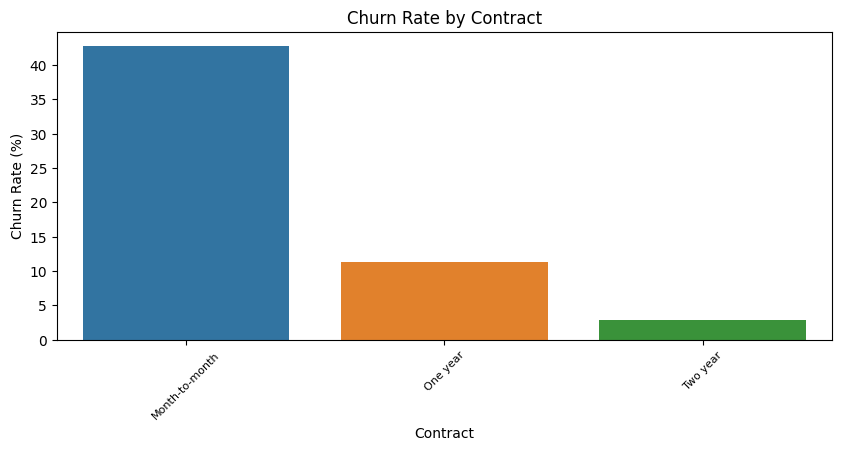

As p=0.0 < 0.05, PaperlessBilling is significantly associated with Churn (Cramer's v=0.1911405817441778).


,PaperlessBilling,Churn,rate
1,No,Yes,16.330084
3,Yes,Yes,33.565092
0,No,No,83.669916
2,Yes,No,66.434908


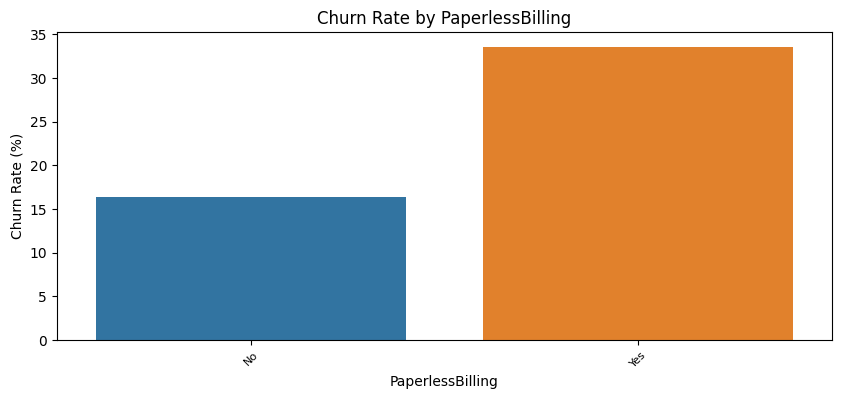

As p=0.0 < 0.05, PaymentMethod is significantly associated with Churn (Cramer's v=0.3026771381187204).


,PaymentMethod,Churn,rate
1,Bank transfer (automatic),Yes,16.709845
3,Credit card (automatic),Yes,15.243101
5,Electronic check,Yes,45.285412
7,Mailed check,Yes,19.106700
0,Bank transfer (automatic),No,83.290155
2,Credit card (automatic),No,84.756899
4,Electronic check,No,54.714588
6,Mailed check,No,80.893300


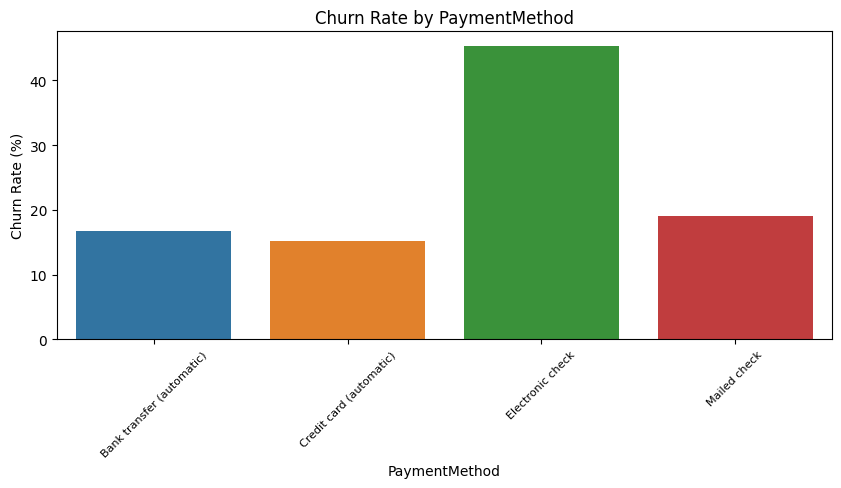

In [ ]:
for cat in cat_cols:
    # Compute correlation strength
    chi_square(df=data, cat1=cat, cat2="Churn")

    # Compute and plot churn rate by category
    churn_rate = data.groupby(cat)["Churn"].value_counts(normalize=True).rename("rate").mul(100).reset_index().sort_values(by="Churn", ascending=False)
    churn_yes = churn_rate[churn_rate["Churn"] == "Yes"]
    display(churn_rate)

    plt.figure(figsize=(10, 4))
    barplot(cat, churn_yes)